In [1]:
import pandas as pd
df = pd.read_csv('gg.csv')
df

,Dialogue,Summaries
0,B: Okay .\nB: Right .\nB: Um well this is the ...,The project manager introduced the upcoming pr...
1,B: Is that alright now ?\nB: Okay .\nB: Sorry ...,The project manager briefed the team on some n...
2,A: 'S to do now is to decide how to fulfil wha...,The project manager recapped the decisions mad...
3,B: Okay we all all set ?\nB: Right .\nB: Well ...,The project manager recapped the decisions mad...
4,"C: .\nD: .\nD: .\nB: Okay , well I think we're...",The team members introduced themselves to each...
...,...,...
132,B: .\nD: .\nA: Do you need to change anything ...,"For the conceptual design, the marketing exper..."
133,A: .\nA: .\nA: .\nB: .\nC: .\nD: .\nB: That's ...,The UI and ID presented a prototype drawing of...
134,"A: Okay , good morning .\nA: This is our first...",The goal of the project is to design an origin...
135,D: .\nD: .\nD: .\nD: .\nA: Wait for the market...,Customers are willing to pay more for fancier ...


In [2]:
text = df['Dialogue'][1]
summry = df['Summaries'][1]

In [3]:
from transformers import pipeline, AutoTokenizer
#summarizer = pipeline("summarization", model="knkarthick/MEETING_SUMMARY")
#summarizer = pipeline("summarization", model="facebook/bart-large-cnn")
#summarizer = pipeline("summarization", model="google/pegasus-large")
tokenizer = AutoTokenizer.from_pretrained("google/pegasus-large")

C:\Users\kashy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Token indices sequence length is longer than the specified maximum sequence length for this model (4676 > 1024). Running this sequence through the model will result in indexing errors


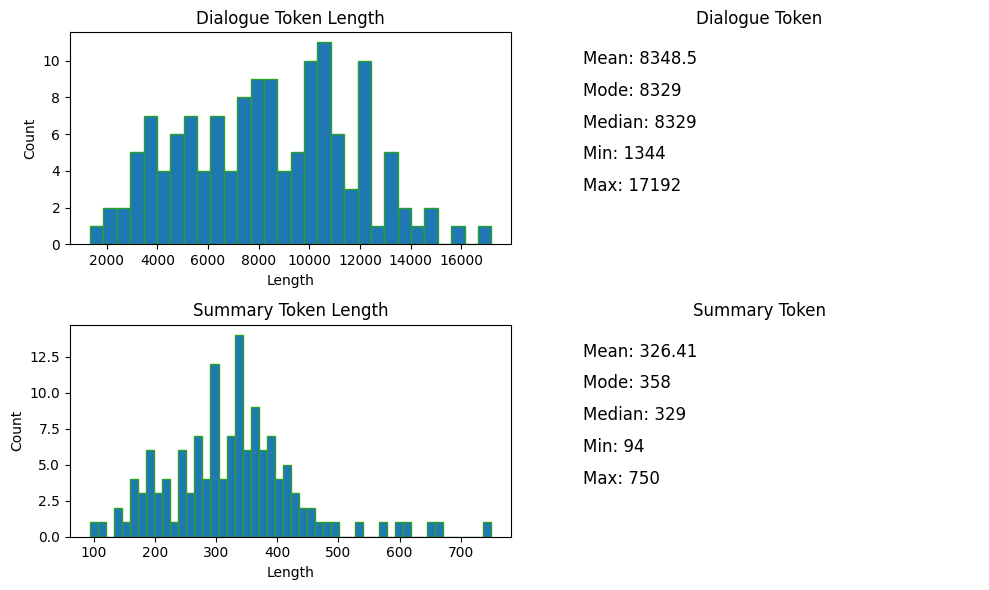

In [4]:
import matplotlib.pyplot as plt
import statistics

dialogue_token_len = list(len(tokenizer.encode(s)) for s in df['Dialogue'])
summary_token_len = list(len(tokenizer.encode(s)) for s in df['Summaries'])

fig, axes = plt.subplots(2, 2, figsize=(10, 6) )
axes[0,0].hist(dialogue_token_len, bins = 30, color = 'C0', edgecolor = 'C2' )
axes[0,0].set_title("Dialogue Token Length")
axes[0,0].set_xlabel("Length")
axes[0,0].set_ylabel("Count")

axes[0,1].set_title("Dialogue Token")
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['bottom'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)
axes[0,1].spines['left'].set_visible(False)
axes[0,1].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
axes[0,1].text(0.1, 0.85, "Mean: {}".format(round(statistics.mean(dialogue_token_len), 2)), fontsize=12)
axes[0,1].text(0.1, 0.70, "Mode: {}".format(statistics.mode(dialogue_token_len)), fontsize=12)
axes[0,1].text(0.1, 0.55, "Median: {}".format(statistics.median(dialogue_token_len)), fontsize=12)
axes[0,1].text(0.1, 0.40, "Min: {}".format(min(dialogue_token_len)), fontsize=12)
axes[0,1].text(0.1, 0.25, "Max: {}".format(max(dialogue_token_len)), fontsize=12)

axes[1,0].hist(summary_token_len, bins = 50, color = 'C0', edgecolor = 'C2' )
axes[1,0].set_title("Summary Token Length")
axes[1,0].set_xlabel("Length")
axes[1,0].set_ylabel("Count")

axes[1,1].set_title("Summary Token")
axes[1,1].spines['top'].set_visible(False)
axes[1,1].spines['bottom'].set_visible(False)
axes[1,1].spines['right'].set_visible(False)
axes[1,1].spines['left'].set_visible(False)
axes[1,1].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
axes[1,1].text(0.1, 0.85, "Mean: {}".format(round(statistics.mean(summary_token_len), 2)), fontsize=12)
axes[1,1].text(0.1, 0.70, "Mode: {}".format(statistics.mode(summary_token_len)), fontsize=12)
axes[1,1].text(0.1, 0.55, "Median: {}".format(statistics.median(summary_token_len)), fontsize=12)
axes[1,1].text(0.1, 0.40, "Min: {}".format(min(summary_token_len)), fontsize=12)
axes[1,1].text(0.1, 0.25, "Max: {}".format(max(summary_token_len)), fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
import numpy as np

ratios = []
for i in range(len(summary_token_len)):
    ratio = dialogue_token_len[i] / summary_token_len[i]
    ratios.append(ratio)

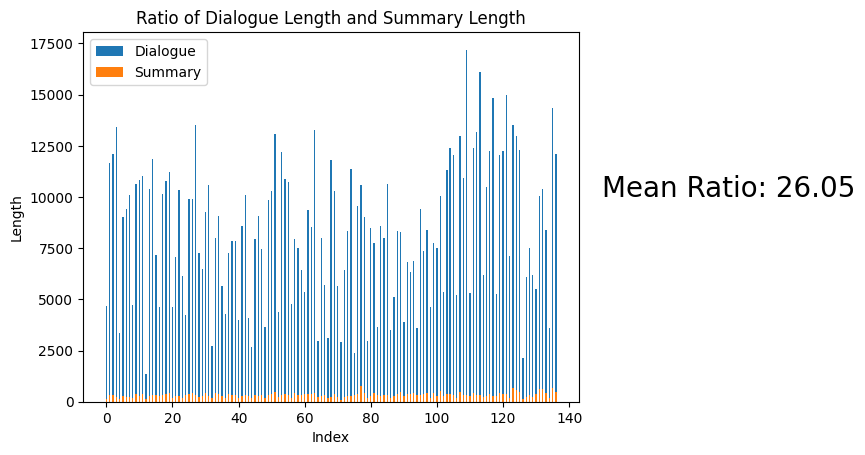

In [6]:
x = np.arange(len(summary_token_len))

plt.bar(x, dialogue_token_len, width=0.4, label='Dialogue', align='center')
plt.bar(x, summary_token_len, width=0.4, label='Summary', align='center')

plt.xlabel('Index')
plt.ylabel('Length')
plt.title('Ratio of Dialogue Length and Summary Length')
plt.text(150, 10000, "Mean Ratio: {}".format(round(statistics.mean(ratios), 2)), fontsize=20)
plt.legend()

plt.show()

In [7]:
print(text)

B: Is that alright now ?
B: Okay .
B: Sorry ?
B: Okay , everybody all set to start the meeting ?
B: Okay , we've got half an hour for this one um to uh discuss the um functional design .
D: Could you plug me in ?
D: Okay .
D: Thanks .
B: All ready to go ?
B: Okay .
D: Okay .
B: Um so hopefully you've all been working away , and I've put the minutes of the last meeting in the project folder .
B: Um so I guess just to to recap on uh what we did last time .
B: Um kind of uh got to know each other a little bit and uh got familiar with all the equipment and started to discuss um a bit about the project , you know , cost-wise how much how much money we had to s Um just want to tell you that you have three new requirements , um which is the The first one is that um uh the company's decided that teletext is outdated uh because of how popular the internet is .
B: Nobody uses teletext very much anymore , so we don't really need to consider that in the functionality of the of the remote control .

In [8]:
auto_tokens = (tokenizer(text))
len(auto_tokens.input_ids)

11655

In [9]:
import nltk
nltk.download('punkt')
tokens = nltk.word_tokenize(text)
len(tokens)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\kashy\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


9822

In [10]:
# Tokenize the sentences and count the total number of tokens
import nltk
def count_tokens(sentences):
    total_tokens = 0
    for sentence in sentences:
        tokens = nltk.word_tokenize(sentence)
        total_tokens += len(tokens)
    print("Total number of tokens is {}.".format(total_tokens))

# Splitting Sentences 

In [11]:
# Split text into sentences
import re
sentences = re.split(r'(?<=[.!?])\s+', text)

# Remve left colums
for i in range(len(sentences)):
    sentences[i] = sentences[i][3:]

count_tokens(sentences)

Total number of tokens is 8439.


# Removing stopwords

In [12]:
# Removing stopwords
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
stopwords_set = set(stopwords.words('english'))
stopwords_removed = []
for sentence in sentences:
    words = sentence.split()
    filtered_words = [word for word in words if word.lower() not in stopwords_set]
    processed_sentence = ' '.join(filtered_words)
    stopwords_removed.append(processed_sentence)

count_tokens(stopwords_removed)

Total number of tokens is 4896.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kashy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
stopwords_removed

['alright ?',
 'Okay .',
 'Sorry ?',
 'Okay , everybody set start meeting ?',
 "Okay , we've got half hour one um uh discuss um functional design .",
 'Could plug ?',
 'Okay .',
 'Thanks .',
 'ready go ?',
 'Okay .',
 'Okay .',
 "Um hopefully working away , I've put minutes last meeting project folder .",
 'Um guess recap uh last time .',
 "Um kind uh got know little bit uh got familiar equipment started discuss um bit project , know , cost-wise much much money Um want tell three new requirements , um first one um uh company's decided teletext outdated uh popular internet .",
 'Nobody uses teletext much anymore , really need consider functionality remote control .',
 "'Kay .",
 "Um they've also suggested um use remote control control television , V_C_R_ , D_V_D_ anything else .",
 "think worry project becomes complex it'll affect um long takes us get production , time market .",
 'Okay .',
 "um , we're gonna keep simple it'll control T_V_ .",
 'thing company want corporate colour sloga

# Remove smol sentences

In [14]:
smol_sentences_removed = []
smol_sentences = []
threshold = 3

for sentence in stopwords_removed:
    if len(sentence.split()) >= threshold:
        smol_sentences_removed.append(sentence)
    else:
        smol_sentences.append(sentence)

count_tokens(smol_sentences_removed)

Total number of tokens is 4294.


In [15]:
smol_sentences_removed

['Okay , everybody set start meeting ?',
 "Okay , we've got half hour one um uh discuss um functional design .",
 'Could plug ?',
 'ready go ?',
 "Um hopefully working away , I've put minutes last meeting project folder .",
 'Um guess recap uh last time .',
 "Um kind uh got know little bit uh got familiar equipment started discuss um bit project , know , cost-wise much much money Um want tell three new requirements , um first one um uh company's decided teletext outdated uh popular internet .",
 'Nobody uses teletext much anymore , really need consider functionality remote control .',
 "Um they've also suggested um use remote control control television , V_C_R_ , D_V_D_ anything else .",
 "think worry project becomes complex it'll affect um long takes us get production , time market .",
 "um , we're gonna keep simple it'll control T_V_ .",
 'thing company want corporate colour slogan implemented new design .',
 "Um I'm entirely sure corporate colour .",
 'might yellow , seems lot yello

In [16]:
smol_sentences

['alright ?',
 'Okay .',
 'Sorry ?',
 'Okay .',
 'Thanks .',
 'Okay .',
 'Okay .',
 "'Kay .",
 'Okay .',
 'Sure .',
 'Mm-hmm .',
 'Right .',
 'Okay .',
 'Alright .',
 'Sorry .',
 'Oop .',
 'Um .',
 'Mm-hmm .',
 'Mm-hmm .',
 '',
 'Okay .',
 'Yeah .',
 'Larger ?',
 'Yeah .',
 'Yeah .',
 'Sure .',
 'Mm-hmm .',
 'Mm-hmm .',
 'Mm-hmm .',
 'Mm-hmm .',
 'Mm-hmm .',
 'Uh-huh .',
 'Okay .',
 '?',
 'Yeah .',
 'Yeah .',
 '?',
 '?',
 'Yeah .',
 'Mm .',
 'right ?',
 'Yeah .',
 'Mm-hmm .',
 'Yeah .',
 'Yep .',
 'Okay .',
 'Yeah .',
 '.',
 '.',
 'Mm-hmm .',
 'Yeah .',
 'Sure .',
 '.',
 '.',
 '.',
 'Yeah .',
 'switch .',
 'Okay .',
 'Right .',
 'Um .',
 'Okay .',
 'Okay .',
 'Okay .',
 'Alright .',
 'Yeah .',
 'Mm .',
 'Okay .',
 'Mm-hmm .',
 'Yep .',
 'Nope .',
 'Try .',
 'Wait .',
 'Okay .',
 'go .',
 'Okay .',
 'Okay .',
 'Right .',
 'go .',
 'Okay .',
 'Alright .',
 'Okay .',
 'Yeah .',
 'Um .',
 'Mm-hmm .',
 'Mm-hmm .',
 'Um .',
 'Mm-hmm .',
 'Okay .',
 'Yeah .',
 'Okay .',
 'Mm .',
 'Yeah .',
 '

# Combining Sentences into a single sentence

In [17]:
# Combining Sentences into a single sentence
combined_string = ' '.join(smol_sentences_removed)
print(combined_string)

Okay , everybody set start meeting ? Okay , we've got half hour one um uh discuss um functional design . Could plug ? ready go ? Um hopefully working away , I've put minutes last meeting project folder . Um guess recap uh last time . Um kind uh got know little bit uh got familiar equipment started discuss um bit project , know , cost-wise much much money Um want tell three new requirements , um first one um uh company's decided teletext outdated uh popular internet . Nobody uses teletext much anymore , really need consider functionality remote control . Um they've also suggested um use remote control control television , V_C_R_ , D_V_D_ anything else . think worry project becomes complex it'll affect um long takes us get production , time market . um , we're gonna keep simple it'll control T_V_ . thing company want corporate colour slogan implemented new design . Um I'm entirely sure corporate colour . might yellow , seems lot yellow everywhere . slogan , like actual written slogan , e

# Making chunks

In [18]:
sentences = smol_sentences_removed

In [19]:
length = 0
chunk = ""
chunks = []
count = -1
for sentence in sentences:
    count += 1
    combined_length = len(tokenizer.tokenize(sentence)) + length # add the no. of sentence tokens to the length counter

    if combined_length  <= tokenizer.max_len_single_sentence: # if it doesn't exceed
        chunk += sentence + " " # add the  sentence to the chunk
        length = combined_length # update the length counter

        # if it is the last sentence
        if count == len(sentences) - 1:
            chunks.append(chunk.strip()) # save the chunk

    else: 
        chunks.append(chunk.strip()) # save the chunk
    
        # reset 
        length = 0 
        chunk = ""

        # take care of the overflow sentence
        chunk += sentence + " "
        length = len(tokenizer.tokenize(sentence))
len(chunks)

6

In [20]:
[len(tokenizer.tokenize(c)) for c in chunks]

[1009, 1004, 1020, 1020, 1013, 361]

In [21]:
[len(tokenizer(c).input_ids) for c in chunks]

[1010, 1005, 1021, 1021, 1014, 362]

In [22]:
inputs = [tokenizer(chunk, return_tensors="pt") for chunk in chunks]

# Summarization

In [23]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
checkpoint = "google/pegasus-large"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForSeq2SeqLM.from_pretrained(checkpoint)

Some weights of PegasusForConditionalGeneration were not initialized from the model checkpoint at google/pegasus-large and are newly initialized: ['model.encoder.embed_positions.weight', 'model.decoder.embed_positions.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [24]:
model.generate??

Signature:
model.generate(
    inputs: Optional[torch.Tensor] = None,
    generation_config: Optional[transformers.generation.configuration_utils.GenerationConfig] = None,
    logits_processor: Optional[transformers.generation.logits_process.LogitsProcessorList] = None,
    stopping_criteria: Optional[transformers.generation.stopping_criteria.StoppingCriteriaList] = None,
    prefix_allowed_tokens_fn: Optional[Callable[[int, torch.Tensor], List[int]]] = None,
    synced_gpus: Optional[bool] = None,
    assistant_model: Optional[ForwardRef('PreTrainedModel')] = None,
    streamer: Optional[ForwardRef('BaseStreamer')] = None,
    negative_prompt_ids: Optional[torch.Tensor] = None,
    negative_prompt_attention_mask: Optional[torch.Tensor] = None,
    **kwargs,
) -> Union[transformers.generation.utils.GreedySearchEncoderDecoderOutput, transformers.generation.utils.GreedySearchDecoderOnlyOutput, transformers.generation.utils.SampleEncoderDecoderOutput, transformers.generation.utils.SampleD

In [25]:
for input in inputs:
    output = model.generate(**input)
    print(tokenizer.decode(*output, skip_special_tokens=True))

Um kind uh got know little bit uh got familiar equipment started discuss um bit project, know, cost-wise much much money Um want tell three new requirements, um first one um uh company's decided teletext outdated uh popular internet. Um they've also suggested um use remote control control television, V_C_R_, D_V_D_ anything else. Um they've also suggested um use remote control control television, V_C_R_, D_V_D_ anything else. Um Right um design I've look online, I've look homepage, given us um insp inspiration previous products. Um Right um design I've look online, I've look homepage, given us um insp inspiration previous products. Um I've look previous products see offer um would like ask guys um ideas design end meeting.
Would like mine um channels like numbers thing, um Um, yeah. God, wou would say that's required, mean there's way anybody's gonna buy remote control days can't actually individually select channels, mean would anybody disagree? Um, else, uh need worry teletext, need 

In [26]:
from transformers import pipeline
summarizer = pipeline("summarization", model="knkarthick/MEETING_SUMMARY")
summarizer(chunks[0])

C:\Users\kashy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\kashy\.cache\huggingface\hub. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to see activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


[{'summary_text': 'The meeting is about putting fashion electronics together. There are three new requirements: teletext, control T_V_ and incorporate the corporate colour slogan and implement the idea slogan. The project is complicated and takes a lot of time.'}]

In [27]:
dialogue_token_len = [len(tokenizer.encode(s)) for s in combined_string ]
dialogue_token_len

[2,
 2,
 2,
 2,
 1,
 3,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 1,
 3,
 2,
 3,
 1,
 3,
 3,
 2,
 2,
 3,
 1,
 2,
 2,
 2,
 3,
 2,
 2,
 2,
 1,
 3,
 1,
 2,
 2,
 2,
 2,
 1,
 3,
 1,
 2,
 2,
 2,
 2,
 2,
 1,
 2,
 2,
 3,
 1,
 2,
 2,
 2,
 2,
 1,
 2,
 2,
 2,
 2,
 1,
 2,
 2,
 2,
 1,
 2,
 2,
 1,
 2,
 2,
 1,
 2,
 2,
 3,
 2,
 2,
 3,
 3,
 1,
 2,
 2,
 1,
 2,
 2,
 2,
 2,
 3,
 2,
 2,
 2,
 2,
 2,
 1,
 2,
 2,
 3,
 2,
 2,
 2,
 1,
 3,
 1,
 2,
 2,
 2,
 2,
 2,
 1,
 2,
 2,
 2,
 2,
 1,
 3,
 1,
 2,
 2,
 2,
 2,
 2,
 1,
 2,
 2,
 1,
 3,
 1,
 2,
 2,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 1,
 2,
 2,
 2,
 2,
 1,
 3,
 1,
 2,
 2,
 2,
 2,
 1,
 2,
 2,
 3,
 1,
 2,
 2,
 2,
 2,
 3,
 2,
 3,
 1,
 2,
 2,
 3,
 3,
 1,
 2,
 2,
 2,
 3,
 2,
 2,
 2,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 3,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 1,
 3,
 1,
 2,
 2,
 1,
 2,
 2,
 2,
 3,
 3,
 1,
 2,
 2,
 2,
 2,
 2,
 1,
 2,
 2,
 1,
 2,
 2,
 3,
 3,
 1,
 3,
 2,
 2,
 2,
 1,
 3,
 1,
 2,
 2,
 1,
 2,
 2,
 2,
 2,
 1,
 2,
 2,
 1,
 2,
 2,
 3,
 1,
 2,


In [28]:
final_text = ''.join(sentences)
final_text = final_text.replace(' .', '. ')
final_text

"Okay , everybody set start meeting ?Okay , we've got half hour one um uh discuss um functional design. Could plug ?ready go ?Um hopefully working away , I've put minutes last meeting project folder. Um guess recap uh last time. Um kind uh got know little bit uh got familiar equipment started discuss um bit project , know , cost-wise much much money Um want tell three new requirements , um first one um uh company's decided teletext outdated uh popular internet. Nobody uses teletext much anymore , really need consider functionality remote control. Um they've also suggested um use remote control control television , V_C_R_ , D_V_D_ anything else. think worry project becomes complex it'll affect um long takes us get production , time market. um , we're gonna keep simple it'll control T_V_. thing company want corporate colour slogan implemented new design. Um I'm entirely sure corporate colour. might yellow , seems lot yellow everywhere. slogan , like actual written slogan , embody idea sl

In [30]:
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL", "rougeLsum"], use_stemmer=True)

In [31]:
extracttive = '''
Um kind uh got know little bit uh got familiar equipment started discuss um bit project, know, cost-wise much much money Um want tell three new requirements, um first one um uh company's decided teletext outdated uh popular internet. Um they've also suggested um use remote control control television, V_C_R_, D_V_D_ anything else. Um they've also suggested um use remote control control television, V_C_R_, D_V_D_ anything else. Um Right um design I've look online, I've look homepage, given us um insp inspiration previous products. Um Right um design I've look online, I've look homepage, given us um insp inspiration previous products. Um I've look previous products see offer um would like ask guys um ideas design end meeting.
Would like mine um channels like numbers thing, um Um, yeah. God, wou would say that's required, mean there's way anybody's gonna buy remote control days can't actually individually select channels, mean would anybody disagree? Um, else, uh need worry teletext, need worry V_C_R_, uh kind like display controls think need worry, know like brightness contrast? Um, start um sort uh bit, um need find exactly um add things they're possible. Well, one one way would look um would approach different controls terms um like control types, user clear want go. Um, start um sort uh bit, um need find exactly um add things they're possible.
guess we're looking people want h technology, tend use simple controls overall find remote controls something really appeal. think we're we're trying take like sorta like three different um inspirations, know, one want uh something that's high-tech want seem easy. uh mention Craig uh showing us ideas actually try group controls, look like big panel, kinda like look, know, new computer keyboard, something quite explanatory. installing new remote control something people Um, think it'll mid range high end market, terms people. Um people uh additionally liking appearance products, wanna think wanna take sort of techie features um put unit people like. Yeah, know c looking Craig um Craig's uh thirty ideas sorta tell maybe wanna try um least five different things wanna include. Well, um one things decide end meeting we're gonna um who's target audience, target market.
think one thing try avoid say use speech recognition right, um, based go everybody's saying, right, want something simple. Um, I'm saying we're we're trying lock particular kind technology, rather focusing exactly features we're gonna say,, know, say speech recognition good, speech recognition good. maybe suggest think speech recognition, anyway something used fulfil function, end day look technology, look function first. Uh okay, well wanna um give us presentation know um might good idea deliver presentations discuss, we're right, exactly, yeah. Oh something that's occurred well make um speech reco incorporate speech recognition, that's um people um maybe physical disability well. We've used, we're familiar, we're can't n narrowed um exactly things we're trying fulfil, like Besides basics, think back back minds know basics.
Um might one consideration would transmission remote control T_V_ example. Okay, um gonna restrict using traditional technologies infra-red thing? Well well worry expressed new requirements made complex would e would effect um long long took us get market, th suspect might good idea restrict kind creative influence user interface worry much uh transmit um mean tried tested intra-red, could stay tha Mm-hmm Oh, yeah. may require, know, um something natural, guess, know, hold, signal user, push button maybe start talking.
Okay, gonna um audio gonna like know bass settings actual volume hi Okay. Okay, visual Okay, brightness, contrast, things like, actual device things, like channel watching, turning, stuff like. Um yeah, guess things think know like fact gotta look good, we're we're, know, targeting.'''

In [32]:
scores = scorer.score(extracttive, summry)

In [33]:
scores

{'rouge1': Score(precision=0.22108843537414966, recall=0.09803921568627451, fmeasure=0.13584117032392892),
 'rouge2': Score(precision=0.023890784982935155, recall=0.010574018126888218, fmeasure=0.014659685863874344),
 'rougeL': Score(precision=0.08503401360544217, recall=0.03770739064856712, fmeasure=0.0522466039707419),
 'rougeLsum': Score(precision=0.20068027210884354, recall=0.0889894419306184, fmeasure=0.12330198537095088)}

In [34]:
from transformers import pipeline
summarizer = pipeline("summarization", model="knkarthick/MEETING_SUMMARY")
summarizer(extracttive)

[{'summary_text': 'The company has decided teletext is outdated and needs a new remote control control. The company is planning to create a new product with speech recognition and focusing on features for high-end market.'}]